In [1]:
import numpy as np
import matplotlib.pyplot as plt


def plot_triangle(data, title=None, fontsize=13, figsize=(9, 9)):
    """
    Plot a triangular array.

    - All grid lines and numbers are pure black.
    - figsize controls the physical size of the output figure.
    """

    n = len(data)
    h = np.sqrt(3) / 2

    fig, ax = plt.subplots(figsize=figsize)

    # ----------------------------
    # 1. Draw triangular grid
    # ----------------------------

    # Horizontal lines
    for r in range(n + 1):
        y = r * h
        x_left = r / 2
        x_right = n - r / 2

        ax.plot(
            [x_left, x_right],
            [y, y],
            color="black",
            linewidth=1
        )

    # / direction
    for k in range(n + 1):
        x0 = k
        length = n - k

        ax.plot(
            [x0, x0 + length / 2],
            [0, length * h],
            color="black",
            linewidth=1
        )

    # \ direction
    for k in range(n + 1):
        x0 = k
        length = k

        ax.plot(
            [x0, x0 - length / 2],
            [0, length * h],
            color="black",
            linewidth=1
        )

    # ----------------------------
    # 2. Place numbers
    # ----------------------------

    for row_from_top, row in enumerate(data):

        level = n - 1 - row_from_top
        y_base = level * h

        expected = 2 * row_from_top + 1

        if len(row) != expected:
            raise ValueError(
                f"Row {row_from_top + 1} must contain "
                f"{expected} entries, but contains {len(row)}."
            )

        x_start = level / 2

        for j, value in enumerate(row):

            if j % 2 == 0:
                # upward triangle
                x = x_start + j / 2 + 0.5
                y = y_base + h / 3

            else:
                # downward triangle
                x = x_start + (j + 1) / 2
                y = y_base + 2 * h / 3

            ax.text(
                x,
                y,
                str(value),
                ha="center",
                va="center",
                fontsize=fontsize,
                color="black"
            )

    # ----------------------------
    # 3. Figure settings
    # ----------------------------

    ax.set_aspect("equal")
    ax.axis("off")

    ax.set_xlim(-0.1, n + 0.1)
    ax.set_ylim(-0.1, n * h + 0.2)

    if title is not None:
        ax.set_title(
            str(title),
            fontsize=fontsize + 2,
            color="black",
            pad=8
        )

    plt.tight_layout(pad=0.2)
    plt.show()



def plot_triangle_multi(
    labels,
    values,
    title=None,
    fontsize=13,
    label_fontsize=None,
    figsize=(9, 9),
    vertical_gap=0.09
):
    """
    Plot a triangular array with labels and values.

    - labels: triangular array of labels
    - values: triangular array of numerical values
    - Label is displayed above.
    - Value is displayed below.
    - All grid lines and text are pure black.
    - figsize controls the physical size of the output figure.
    - vertical_gap controls the vertical separation between label and value.

    Example for n=3:

    labels = [
        ["A"],
        ["B0", "B1", "B2"],
        ["C0", "C1", "C2", "C3", "C4"]
    ]

    values = [
        [1],
        [2, 3, 4],
        [5, 6, 7, 8, 9]
    ]
    """

    n = len(values)
    h = np.sqrt(3) / 2

    if len(labels) != n:
        raise ValueError(
            f"labels has {len(labels)} rows, "
            f"but values has {n} rows."
        )

    if label_fontsize is None:
        label_fontsize = fontsize * 0.75

    fig, ax = plt.subplots(figsize=figsize)

    # ----------------------------
    # 1. Draw triangular grid
    # ----------------------------

    # Horizontal lines
    for r in range(n + 1):
        y = r * h
        x_left = r / 2
        x_right = n - r / 2

        ax.plot(
            [x_left, x_right],
            [y, y],
            color="black",
            linewidth=1
        )

    # / direction
    for k in range(n + 1):
        x0 = k
        length = n - k

        ax.plot(
            [x0, x0 + length / 2],
            [0, length * h],
            color="black",
            linewidth=1
        )

    # \ direction
    for k in range(n + 1):
        x0 = k
        length = k

        ax.plot(
            [x0, x0 - length / 2],
            [0, length * h],
            color="black",
            linewidth=1
        )

    # ----------------------------
    # 2. Place labels and values
    # ----------------------------

    for row_from_top, (label_row, value_row) in enumerate(
        zip(labels, values)
    ):
        level = n - 1 - row_from_top
        y_base = level * h

        expected = 2 * row_from_top + 1

        if len(label_row) != expected:
            raise ValueError(
                f"Label row {row_from_top + 1} must contain "
                f"{expected} entries, but contains {len(label_row)}."
            )

        if len(value_row) != expected:
            raise ValueError(
                f"Value row {row_from_top + 1} must contain "
                f"{expected} entries, but contains {len(value_row)}."
            )

        x_start = level / 2

        for j, (label, value) in enumerate(
            zip(label_row, value_row)
        ):

            if j % 2 == 0:
                # upward triangle
                x = x_start + j / 2 + 0.5
                y = y_base + h / 3

            else:
                # downward triangle
                x = x_start + (j + 1) / 2
                y = y_base + 2 * h / 3

            # Label: above
            ax.text(
                x,
                y + vertical_gap,
                str(label),
                ha="center",
                va="center",
                fontsize=label_fontsize,
                color="black"
            )

            # Value: below
            ax.text(
                x,
                y - vertical_gap,
                str(value),
                ha="center",
                va="center",
                fontsize=fontsize,
                color="black"
            )

    # ----------------------------
    # 3. Figure settings
    # ----------------------------

    ax.set_aspect("equal")
    ax.axis("off")

    ax.set_xlim(-0.1, n + 0.1)
    ax.set_ylim(-0.1, n * h + 0.2)

    if title is not None:
        ax.set_title(
            str(title),
            fontsize=fontsize + 2,
            color="black",
            pad=8
        )

    plt.tight_layout(pad=0.2)
    plt.show()

In [2]:
names = [
    ["N00"],
    ["L02", "N0", "L01"],
    ["J02", "H02", "K0", "H01", "J01"],
    ["G02", "M02", "F02", "I0", "F01", "M01", "G01"],
    ["G12", "E2", "D2", "C02", "B0", "C01", "D1", "E1", "G21"],
    ["J12", "M12", "F12", "C12", "B1", "B3", "B2", "C21", "F21", "M21", "J21"],
    ["L12", "H12", "K1", "I1", "F10", "C10", "D0", "C20", "F20", "I2", "K2", "H21", "L21"],
    ["N11", "N1", "L10", "H10", "J10", "M10", "G10", "E0", "G20", "M20", "J20", "H20", "L20", "N2", "N22"]
]
numbers = [
    [62],
    [28, 11, 25],
    [58, 9, 31, 29, 41],
    [43, 21, 4, 57, 34, 35, 16],
    [2, 45, 36, 44, 42, 0, 50, 23, 37],
    [7, 54, 63, 1, 26, 40, 18, 53, 5, 51, 33],
    [47, 20, 52, 8, 3, 59, 38, 15, 55, 17, 49, 12, 32],
    [30, 27, 22, 46, 6, 56, 61, 14, 13, 39, 19, 48, 10, 24, 60]
]

numberone = [
    [x + 1 for x in row]
    for row in numbers
]

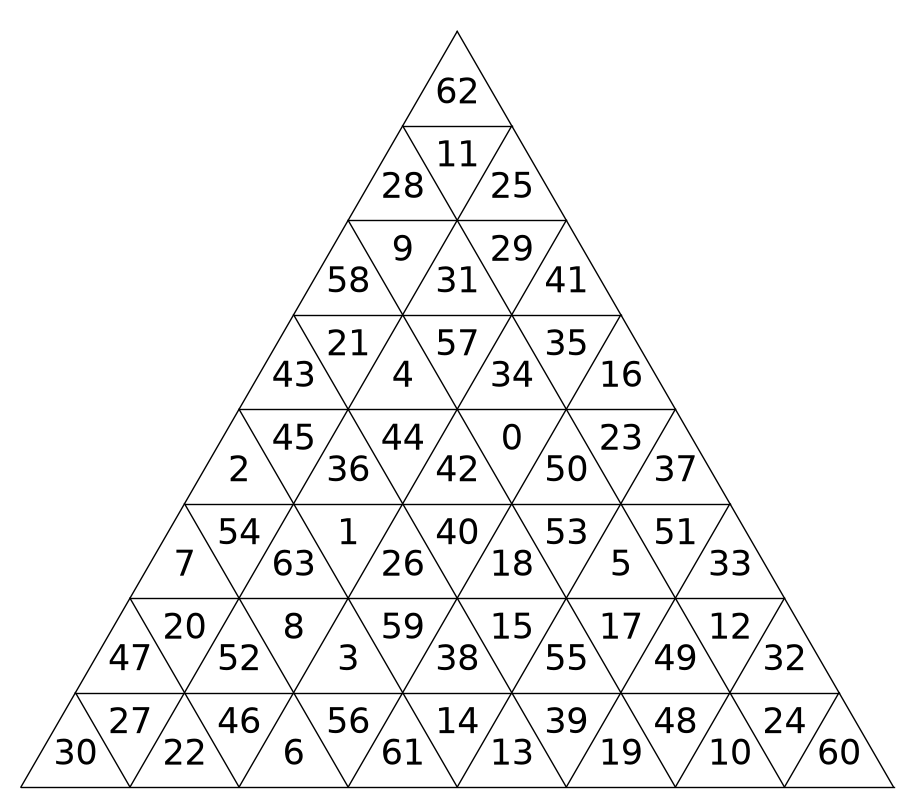

In [17]:
plot_triangle(numbers, fontsize=25)

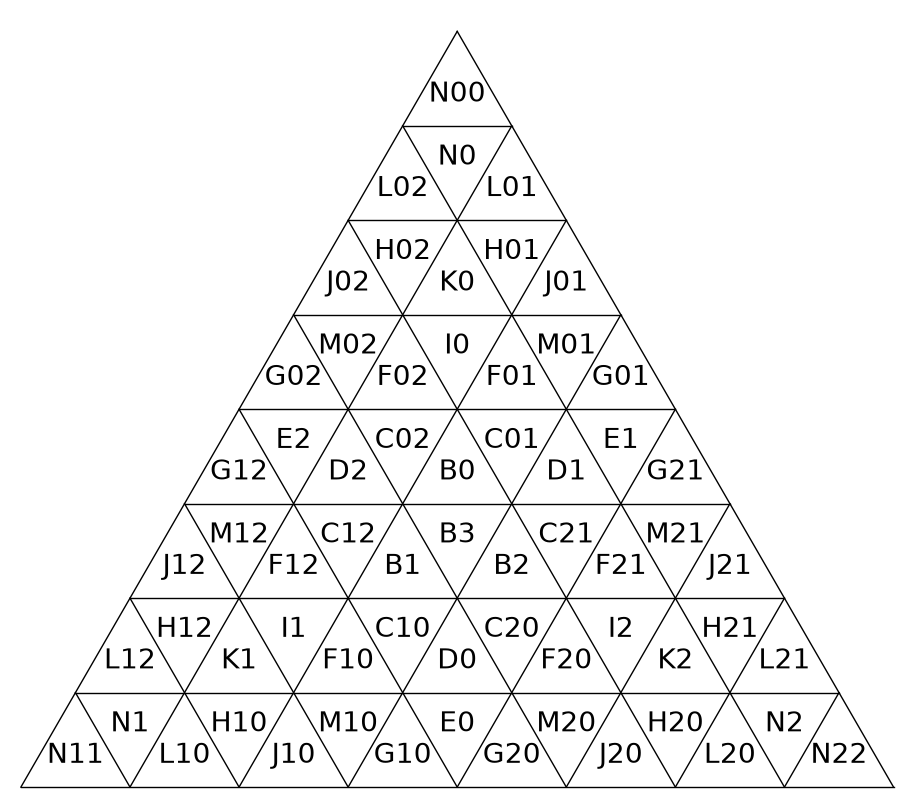

In [4]:
plot_triangle(names, fontsize=20)

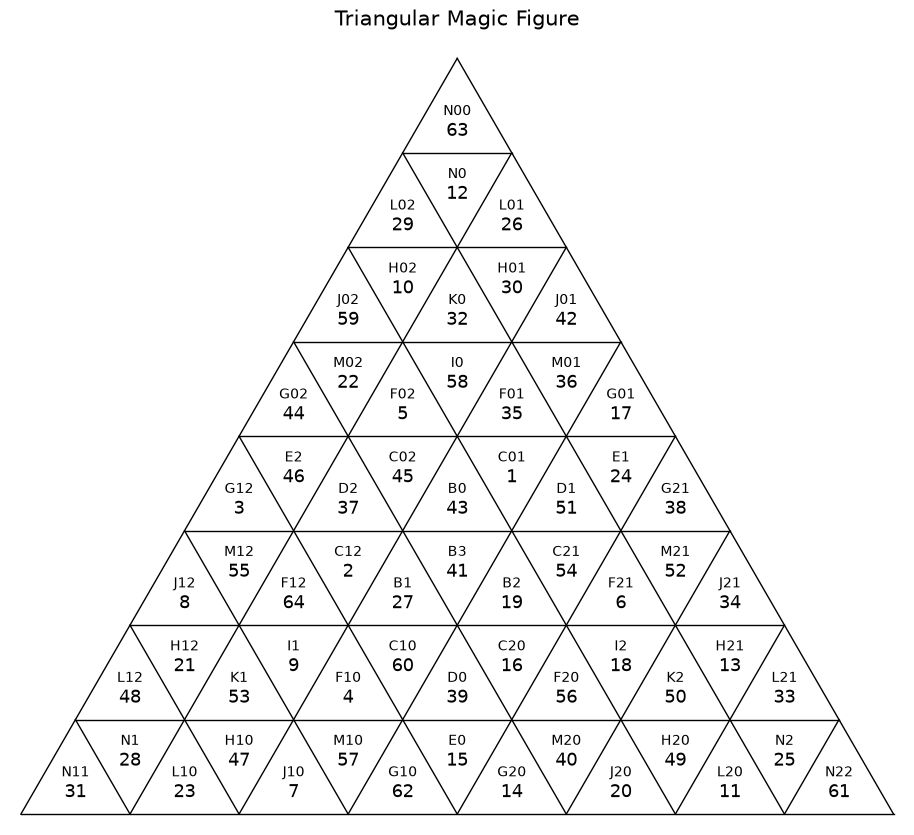

In [5]:
plot_triangle_multi(
    names,
    numberone,
    title="Triangular Magic Figure"
)

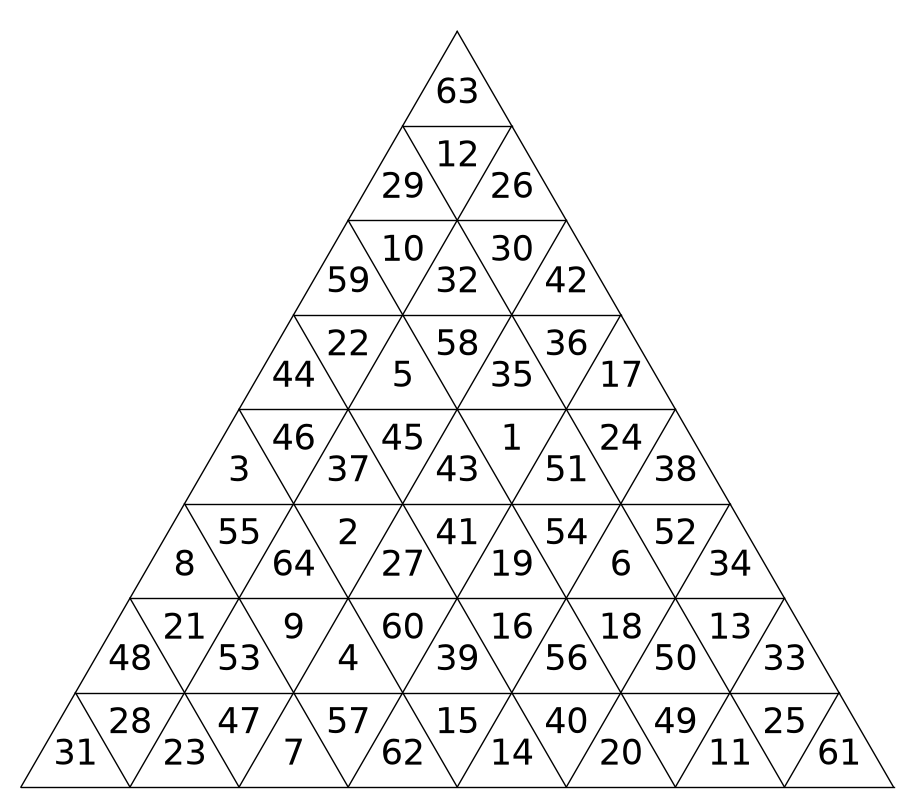

In [19]:
plot_triangle(numberone, fontsize=25)

In [23]:

# C code
ccode='''
#include <stdio.h>
#include <stdint.h>

/* Python's set(range(64)) is represented by a 64-bit occupancy mask. */
enum { C01,C02,C10,C12,C20,C21,D0,E0,F10,F20,D1,E1,F01,F21,
       D2,E2,F02,F12,I0,K0,M01,M02,I1,K1,M10,M12,I2,K2,M20,M21,
       G01,J01,G21,J21,G12,J12,G02,J02,G20,J20,G10,J10,
       H01,H02,L01,L02,H12,L12,L10,H10,H20,L20,L21,H21,
       N0,N00,N1,N11,N2,N22,COUNT };
static int v[COUNT], b[4]={42,26,18,40};
static unsigned long long solutions;
static const unsigned long long solution_limit = 1; /* 원하는 해의 개수 */
static const int groups[][4]={{D0,E0,F10,F20},{D1,E1,F01,F21},
 {D2,E2,F02,F12},{I0,K0,M01,M02},{I1,K1,M10,M12},
 {I2,K2,M20,M21},{G01,J01,G21,J21},{G12,J12,G02,J02},
 {G20,J20,G10,J10},{H01,H02,L01,L02},{H12,L12,L10,H10},
 {H20,L20,L21,H21}};
static const int first[]={D0,D1,D2,I0,I1,I2,G01,G12,G20,H01,H12,H20};

static int reserve(uint64_t used, const int *ids, int n, uint64_t *next) {
    for(int q=0;q<n;q++) {
        int x=v[ids[q]];
        if(x<0 || x>=64 || (used & (UINT64_C(1)<<x))) return 0;
        used |= UINT64_C(1)<<x;
    }
    *next=used;
    return 1;
}
static const int row_lengths[8] = {1, 3, 5, 7, 9, 11, 13, 15};

/* B0~B3은 COUNT~COUNT+3으로 표시 */
static const int rows[8][15] = {
    {N00},
    {L02, N0, L01},
    {J02, H02, K0, H01, J01},
    {G02, M02, F02, I0, F01, M01, G01},
    {G12, E2, D2, C02, COUNT+0, C01, D1, E1, G21},
    {J12, M12, F12, C12, COUNT+1, COUNT+3, COUNT+2,
     C21, F21, M21, J21},
    {L12, H12, K1, I1, F10, C10, D0, C20, F20,
     I2, K2, H21, L21},
    {N11, N1, L10, H10, J10, M10, G10, E0, G20,
     M20, J20, H20, L20, N2, N22}
};

static const char *row_names[8][15] = {
    {"N00"},
    {"L02", "N0", "L01"},
    {"J02", "H02", "K0", "H01", "J01"},
    {"G02", "M02", "F02", "I0", "F01", "M01", "G01"},
    {"G12", "E2", "D2", "C02", "B0", "C01", "D1", "E1", "G21"},
    {"J12", "M12", "F12", "C12", "B1", "B3", "B2",
     "C21", "F21", "M21", "J21"},
    {"L12", "H12", "K1", "I1", "F10", "C10", "D0", "C20",
     "F20", "I2", "K2", "H21", "L21"},
    {"N11", "N1", "L10", "H10", "J10", "M10", "G10",
     "E0", "G20", "M20", "J20", "H20", "L20", "N2", "N22"}
};

static void print_name_rows(void) {
    puts("Names:");
    for (int r = 0; r < 8; r++) {
        for (int c = 0; c < row_lengths[r]; c++)
            printf("%s%s", c ? " " : "", row_names[r][c]);
        putchar('\n');
    }
}

static void print_solution(void) {
    printf("Solution %llu:\n", ++solutions);
    for (int r = 0; r < 8; r++) {
        for (int c = 0; c < row_lengths[r]; c++) {
            int id = rows[r][c];
            int value = (id < COUNT) ? v[id] : b[id - COUNT];
            printf("%s%d", c ? " " : "", value);
        }
        putchar('\n');
    }
}
static void finish(uint64_t used) {
    int rem[6],n=0;
    for(int x=0;x<64;x++) if(!(used&(UINT64_C(1)<<x))) {
        if(n>=6) return;
        rem[n++]=x;
    }
    if(n!=6) return;
    for(int a=0;a<6;a++) for(int bb=a+1;bb<6;bb++) {
        if(rem[a]+rem[bb]+v[L01]+v[L02]!=126) continue;
        for(int c=0;c<6;c++) if(c!=a&&c!=bb)
        for(int d=c+1;d<6;d++) if(d!=a&&d!=bb) {
            if(rem[c]+rem[d]+v[L12]+v[L10]!=126) continue;
            int e=-1,f=-1;
            for(int t=0;t<6;t++) if(t!=a&&t!=bb&&t!=c&&t!=d) {
                if(e<0)e=t; else f=t;
            }
            if(rem[e]+rem[f]+v[L21]+v[L20]!=126) continue;
            v[N0]=rem[a];v[N00]=rem[bb];v[N1]=rem[c];v[N11]=rem[d];
            v[N2]=rem[e];v[N22]=rem[f];print_solution();
            if(solutions>=solution_limit) return;
        }
    }
}
static void stage(int s,uint64_t used) {
    if(solutions>=solution_limit) return;
    if(s==12) { finish(used); return; }
    for(int x=0;x<64;x++) {
        if(solutions>=solution_limit) return;
        if(used & (UINT64_C(1)<<x)) continue;
        v[first[s]]=x;
        switch(s) {
        case 0: v[E0]=126-v[C10]-v[C20]-x; v[F10]=126-b[1]-v[C10]-x; v[F20]=126-b[2]-v[C20]-x; break;
        case 1: v[E1]=126-v[C21]-v[C01]-x; v[F01]=126-b[0]-v[C01]-x; v[F21]=126-b[2]-v[C21]-x; break;
        case 2: v[E2]=126-v[C02]-v[C12]-x; v[F02]=126-b[0]-v[C02]-x; v[F12]=126-b[1]-v[C12]-x; break;
        case 3: v[K0]=126-v[F01]-v[F02]-x; v[M01]=126-v[C01]-v[F01]-x; v[M02]=126-v[C02]-v[F02]-x; break;
        case 4: v[K1]=126-v[F10]-v[F12]-x; v[M10]=126-v[C10]-v[F10]-x; v[M12]=126-v[C12]-v[F12]-x; break;
        case 5: v[K2]=126-v[F20]-v[F21]-x; v[M20]=126-v[C20]-v[F20]-x; v[M21]=126-v[C21]-v[F21]-x; break;
        case 6: v[J01]=126-x-v[M01]-v[F01]; v[G21]=126-v[E1]-v[D1]-x; v[J21]=126-v[G21]-v[M21]-v[F21]; break;
        case 7: v[J12]=126-x-v[M12]-v[F12]; v[G02]=126-v[E2]-v[D2]-x; v[J02]=126-v[G02]-v[M02]-v[F02]; break;
        case 8: v[J20]=126-x-v[M20]-v[F20]; v[G10]=126-v[E0]-v[D0]-x; v[J10]=126-v[G10]-v[M10]-v[F10]; break;
        case 9: v[L01]=126-v[J01]-x-v[K0]; v[L02]=x+v[I0]-v[J02]; v[H02]=126-v[L02]-v[J02]-v[K0]; break;
        case 10: v[L12]=126-v[J12]-x-v[K1]; v[L10]=x+v[I1]-v[J10]; v[H10]=126-v[L10]-v[J10]-v[K1]; break;
        case 11: v[L20]=126-v[J20]-x-v[K2]; v[L21]=x+v[I2]-v[J21]; v[H21]=126-v[L21]-v[J21]-v[K2]; break;
        }
        uint64_t next;
        if(reserve(used,groups[s],4,&next)) stage(s+1,next);
    }
}
static void search_c(int p,uint64_t used) {
    static const int start[]={C01,C12,C20};
    if(solutions>=solution_limit) return;
    if(p==3) { stage(0,used); return; }
    for(int x=0;x<64;x++) {
        if(solutions>=solution_limit) return;
        if(used & (UINT64_C(1)<<x)) continue;
        int ids[2],other;
        v[start[p]]=x;
        if(p==0) {other=C02;v[other]=126-b[0]-b[3]-x;}
        else if(p==1) {other=C10;v[other]=126-b[1]-b[3]-x;}
        else {other=C21;v[other]=126-b[2]-b[3]-x;}
        ids[0]=start[p];ids[1]=other;
        uint64_t next;
        if(reserve(used,ids,2,&next)) search_c(p+1,next);
    }
}
int main(void) {
    uint64_t used = 0;
    for (int k = 0; k < 4; k++)
        used |= UINT64_C(1) << b[k];

    print_name_rows();
    search_c(0, used);
    printf("Total solutions: %llu\n", solutions);
    return 0;
}

'''
print(ccode)


#include <stdio.h>
#include <stdint.h>

/* Python's set(range(64)) is represented by a 64-bit occupancy mask. */
enum { C01,C02,C10,C12,C20,C21,D0,E0,F10,F20,D1,E1,F01,F21,
       D2,E2,F02,F12,I0,K0,M01,M02,I1,K1,M10,M12,I2,K2,M20,M21,
       G01,J01,G21,J21,G12,J12,G02,J02,G20,J20,G10,J10,
       H01,H02,L01,L02,H12,L12,L10,H10,H20,L20,L21,H21,
       N0,N00,N1,N11,N2,N22,COUNT };
static int v[COUNT], b[4]={42,26,18,40};
static unsigned long long solutions;
static const unsigned long long solution_limit = 1; /* 원하는 해의 개수 */
static const int groups[][4]={{D0,E0,F10,F20},{D1,E1,F01,F21},
 {D2,E2,F02,F12},{I0,K0,M01,M02},{I1,K1,M10,M12},
 {I2,K2,M20,M21},{G01,J01,G21,J21},{G12,J12,G02,J02},
 {G20,J20,G10,J10},{H01,H02,L01,L02},{H12,L12,L10,H10},
 {H20,L20,L21,H21}};
static const int first[]={D0,D1,D2,I0,I1,I2,G01,G12,G20,H01,H12,H20};

static int reserve(uint64_t used, const int *ids, int n, uint64_t *next) {
    for(int q=0;q<n;q++) {
        int x=v[ids[q]];
        if(x<0 || x>=64 |

In [25]:
# original Python code
pycode='''
j=0
for i in range(1):
    B=[42, 26, 18, 40]
    for C01 in set(range(64))-set(B):
        C02=126-B[0]-B[3]-C01
        if C02 in set(range(64))-set(B):
            if C02!=C01:
                for C12 in set(range(64))-set(B)-set([C01,C02]):
                    C10=126-B[1]-B[3]-C12
                    if C10 in set(range(64))-set(B)-set([C01,C02]):
                        if C10!=C12:
                            for C20 in set(range(64))-set(B)-set([C01,C02,C10,C12]):
                                C21=126-B[2]-B[3]-C20
                                if C21 in set(range(64))-set(B)-set([C01,C02,C10,C12]):
                                    if C20!=C21:
                                        setC=set([C01,C02,C10,C12,C20,C21])
                                        for D0 in set(range(64))-set(B)-setC:
                                            E0=126-C10-C20-D0
                                            F10=126-B[1]-C10-D0
                                            F20=126-B[2]-C20-D0
                                            if len(set([D0,E0,F10,F20]))==4:
                                                if set([D0,E0,F10,F20]).issubset(set(range(64))-set(B)-setC):
                                                    for D1 in set(range(64))-set(B)-setC-set([D0,E0,F10,F20]):
                                                        E1=126-C21-C01-D1
                                                        F01=126-B[0]-C01-D1
                                                        F21=126-B[2]-C21-D1
                                                        if len(set([D1,E1,F01,F21]))==4:
                                                            if set([D1,E1,F01,F21]).issubset(set(range(64))-set(B)-setC-set([D0,E0,F10,F20])):
                                                                for D2 in set(range(64))-set(B)-setC-set([D0,E0,F10,F20,D1,E1,F01,F21]):
                                                                    E2=126-C02-C12-D2
                                                                    F02=126-B[0]-C02-D2
                                                                    F12=126-B[1]-C12-D2
                                                                    if len(set([D2,E2,F02,F12]))==4:
                                                                        if set([D2,E2,F02,F12]).issubset(set(range(64))-set(B)-setC-set([D0,E0,F10,F20,D1,E1,F01,F21])):
                                                                            set12=set([D0,E0,F10,F20,D1,E1,F01,F21,D2,E2,F02,F12])
                                                                            set42=set(range(64))-set(B)-setC-set12
                                                                            for I0 in set42:
                                                                                K0=126-F01-F02-I0
                                                                                M01=126-C01-F01-I0
                                                                                M02=126-C02-F02-I0
                                                                                if len(set([I0,K0,M01,M02]))==4:
                                                                                    if set([I0,K0,M01,M02]).issubset(set42):
                                                                                        for I1 in set42-set([I0,K0,M01,M02]):
                                                                                            K1=126-F10-F12-I1
                                                                                            M10=126-C10-F10-I1
                                                                                            M12=126-C12-F12-I1
                                                                                            if len(set([I1,K1,M10,M12]))==4:
                                                                                                if set([I1,K1,M10,M12]).issubset(set42-set([I0,K0,M01,M02])):
                                                                                                    for I2 in set42-set([I0,K0,M01,M02,I1,K1,M10,M12]):
                                                                                                        K2=126-F20-F21-I2
                                                                                                        M20=126-C20-F20-I2
                                                                                                        M21=126-C21-F21-I2
                                                                                                        if len(set([I2,K2,M20,M21]))==4:
                                                                                                            if set([I2,K2,M20,M21]).issubset(set42-set([I0,K0,M01,M02,I1,K1,M10,M12])):
                                                                                                                set12s=set([I0,K0,M01,M02,I1,K1,M10,M12,I2,K2,M20,M21])
                                                                                                                set30=set42-set12s
                                                                                                                for G01 in set30:
                                                                                                                    J01=126-G01-M01-F01
                                                                                                                    G21=126-E1-D1-G01
                                                                                                                    J21=126-G21-M21-F21
                                                                                                                    if len(set([G01,J01,G21,J21]))==4:
                                                                                                                        if set([G01,J01,G21,J21]).issubset(set30):
                                                                                                                            for G12 in set30-set([G01,J01,G21,J21]):
                                                                                                                                J12=126-G12-M12-F12
                                                                                                                                G02=126-E2-D2-G12
                                                                                                                                J02=126-G02-M02-F02
                                                                                                                                if len(set([G12,J12,G02,J02]))==4:
                                                                                                                                    if set([G01,J01,G21,J21]).issubset(set30-set([G01,J01,G21,J21])):
                                                                                                                                        for G20 in set30-set([G01,J01,G21,J21,G12,J12,G02,J02]):
                                                                                                                                            J20=126-G20-M20-F20
                                                                                                                                            G10=126-E0-D0-G20
                                                                                                                                            J10=126-G10-M10-F10
                                                                                                                                            if len(set([G20,J20,G10,J10]))==4:
                                                                                                                                                if set([G20,J20,G10,J10]).issubset(set30-set([G01,J01,G21,J21,G12,J12,G02,J02])):
                                                                                                                                                    set18=set30-set([G01,J01,G21,J21,G12,J12,G02,J02,G20,J20,G10,J10])
                                                                                                                                                    for H01 in set18:
                                                                                                                                                        L01=126-J01-H01-K0
                                                                                                                                                        L02=H01+I0-J02
                                                                                                                                                        H02=126-L02-J02-K0
                                                                                                                                                        if len(set([H01,H02,L01,L02]))==4:
                                                                                                                                                            if set([H01,H02,L01,L02]).issubset(set18):
                                                                                                                                                                for H12 in set18-set([H01,H02,L01,L02]):
                                                                                                                                                                    L12=126-J12-H12-K1
                                                                                                                                                                    L10=H12+I1-J10
                                                                                                                                                                    H10=126-L10-J10-K1
                                                                                                                                                                    if len(set([H12,H12,L10,L10]))==4:
                                                                                                                                                                        if set([H12,H12,L10,L10]).issubset(set18-set([H01,H02,L01,L02])):
                                                                                                                                                                            for H20 in set18-set([H01,H02,L01,L02,H12,H12,L10,L10]):
                                                                                                                                                                                L20=126-J20-H20-K2
                                                                                                                                                                                L21=H20+I2-J21
                                                                                                                                                                                H21=126-L21-J21-K2
                                                                                                                                                                                if len(set([H20,H20,L21,L21]))==4:
                                                                                                                                                                                    if set([H20,H20,L21,L21]).issubset(set18-set([H01,H02,L01,L02,H12,H12,L10,L10])):
                                                                                                                                                                                        set6=set18-set([H01,H02,L01,L02,H12,H12,L10,L10,H20,H20,L21,L21])
                                                                                                                                                                                        set6=set18-set([H01,H02,L01,L02,H12,H12,L10,L10,H20,H20,L21,L21])
                                                                                                                                                                                        for [N0, N00] in itertools.combinations(set6, 2):
                                                                                                                                                                                            if N0+N00+L01+L02==126:
                                                                                                                                                                                                for [N1, N11] in itertools.combinations(set6-set([N0, N00]), 2):
                                                                                                                                                                                                    if N1+N11+L12+L10==126:
                                                                                                                                                                                                         for [N2, N22] in itertools.combinations(set6-set([N0, N00,N1, N11]), 2):
                                                                                                                                                                                                             if N2+N22+L21+L20==126:
                                                                                                                                                                                                                 print(i)
                                                                                                                                                                                                                 print(B,[C01,C02,C10,C12,C20,C21],[D0,E0,F10,F20],[D1,E1,F01,F21],[D2,E2,F02,F12],[I0,K0,M01,M02,I1,K1,M10,M12,I2,K2,M20,M21],[G01,J01,G21,J21,G12,J12,G02,J02,G20,J20,G10,J10],[H01,H02,L01,L02,H12,H12,L10,L10,H20,H20,L21,L21],[N0,N00,N1,N11,N2,N22])
                                                                                                                                                                                                                 j+=1
                                                                                                                                        
print(i,j)
'''
print(pycode)


j=0
for i in range(1):
    B=[42, 26, 18, 40]
    for C01 in set(range(64))-set(B):
        C02=126-B[0]-B[3]-C01
        if C02 in set(range(64))-set(B):
            if C02!=C01:
                for C12 in set(range(64))-set(B)-set([C01,C02]):
                    C10=126-B[1]-B[3]-C12
                    if C10 in set(range(64))-set(B)-set([C01,C02]):
                        if C10!=C12:
                            for C20 in set(range(64))-set(B)-set([C01,C02,C10,C12]):
                                C21=126-B[2]-B[3]-C20
                                if C21 in set(range(64))-set(B)-set([C01,C02,C10,C12]):
                                    if C20!=C21:
                                        setC=set([C01,C02,C10,C12,C20,C21])
                                        for D0 in set(range(64))-set(B)-setC:
                                            E0=126-C10-C20-D0
                                            F10=126-B[1]-C10-D0
                                            F20=126